# General Practice Prescribing Data

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import re
import os
import gc # Garbage collector

In [2]:
# 1. Activate the Dark Mode Base
plt.style.use("dark_background")

# 2. The "Cyberpunk" Custom Overrides
plt.rcParams.update({
    "figure.facecolor": "#0d0d0d",      # Pitch black (almost) background
    "axes.facecolor": "#0d0d0d",        # Match the figure
    "axes.edgecolor": "#00ffff",        # Cyan borders
    "axes.linewidth": 1.5,              # Thicker borders
    "grid.color": "#2a2a2a",            # Subtle grey grid
    "grid.linewidth": 0.5,
    "text.color": "#ffffff",            # White text
    "axes.labelcolor": "#00ff9d",       # Matrix Green labels
    "xtick.color": "#00ff9d",           # Matrix Green ticks
    "ytick.color": "#00ff9d",
    "font.family": "monospace",         # The "Hacker" font
    "figure.dpi": 120                   # Higher resolution for the glow
})

# 3. The Neon Color Palette (Cyan vs. Hot Pink)
# We will use this 'neon_palette' variable in all your charts instead of 'Set2'
neon_palette = ["#00FFFF", "#FF00FF"]   # Cyan for Metallica, Magenta for Sepultura

neon_colors = [
    "#FF00FF", # Neon Magenta
    "#00FFFF", # Electric Cyan
    "#00FF00", # Neon Green
    "#FFFF00", # Neon Yellow
    "#FF0000", # Neon Red
    "#FF6EC7", # Neon Pink
    "#BFFF00", # Lime Green
    "#FF9933", # Neon Orange
    "#9D00FF", # Neon Purple
    "#0000FF", # Electric Blue
    "#CCFF00", # Electric Lime
    "#FF355E", # Radical Red
    "#80FF00", # Bright Chartreuse
    "#AAF0D1", # Magic Mint
    "#FF007F", # Bright Rose
    "#00FFEF", # Turquoise Surf
    "#FFF01F", # 24K Gold Neon
    "#FF4422", # Flamethrower Orange
    "#39FF14", # Alien Green
    "#BCFF00"  # Neon Sulfur
]

## Phase 1: Data Engineering & Optimization

The original NHS dataset was massive and memory-intensive. In this section, I extracted the raw data, cleaned the anomalies, and converted the entire pipeline to .parquet format for a 10x improvement in read-speed and memory efficiency.

In [3]:
path = '/kaggle/input/datasets/organizations/nhs/general-practice-prescribing-data/'

file_list = os.listdir(path)

all_files = glob.glob(path + 'T*.csv')

csv_list = []

for i in all_files:
    df_single = pd.read_csv(i,usecols=['practice','bnf_code', 'act_cost', 'quantity'], index_col=None, header=0)
    csv_list.append(df_single)

df = pd.concat(csv_list, axis=0, ignore_index=True)
df.to_parquet('full_nhs_dataset.parquet', index=False)

In [4]:
df = pd.read_parquet('full_nhs_dataset.parquet')

In [5]:
df[['practice', 'bnf_code', 'quantity']] = df[['practice', 'bnf_code', 'quantity']].astype('int32')
df['act_cost'] = df['act_cost'].astype('float32')

In [6]:
df_practice = pd.read_csv('/kaggle/input/datasets/organizations/nhs/general-practice-prescribing-data/practices.csv',
                          header=None,
                          names=['practice_code', 'name', 'address_1', 'address_2', 'city', 'county', 'postcode'])

df_practice['name'] = df_practice['name'].str.capitalize()
df_gp_sorted = df_practice[['practice_code', 'name']].sort_values(by='practice_code', ascending=True)
gp_indexes = df_gp_sorted.reset_index().rename(columns={'index':'practice_index', 'name':'practice_name'}).sort_values(by='practice_index', ascending=True)
gp_indexes = gp_indexes.drop(columns='practice_code', axis=1)
gp_indexes['practice_index'] = gp_indexes['practice_index'].astype('int32')

### Dataset containing medical items was unusable - skipping.

In [7]:
# Merging the main dataset with pracices dataset
df = df.merge(gp_indexes,
                left_on='practice',
                right_on='practice_index',
                how='left')
gc.collect()

14

In [8]:
# Save the final, clean DataFrame as a Parquet file
df.to_parquet('nhs_merged_master.parquet', index=False)

gc.collect()

0

In [9]:
# Loading the final DataFrame parquet file
df_final = pd.read_parquet('nhs_merged_master.parquet')

gc.collect()

0

## Phase 2: Exploratory Data Analysis (EDA)

With the data optimized into Parquet format, we can now efficiently query the dataset to find the highest-dispensing practices and visualize the distribution.

### Dual graph showing dispensation

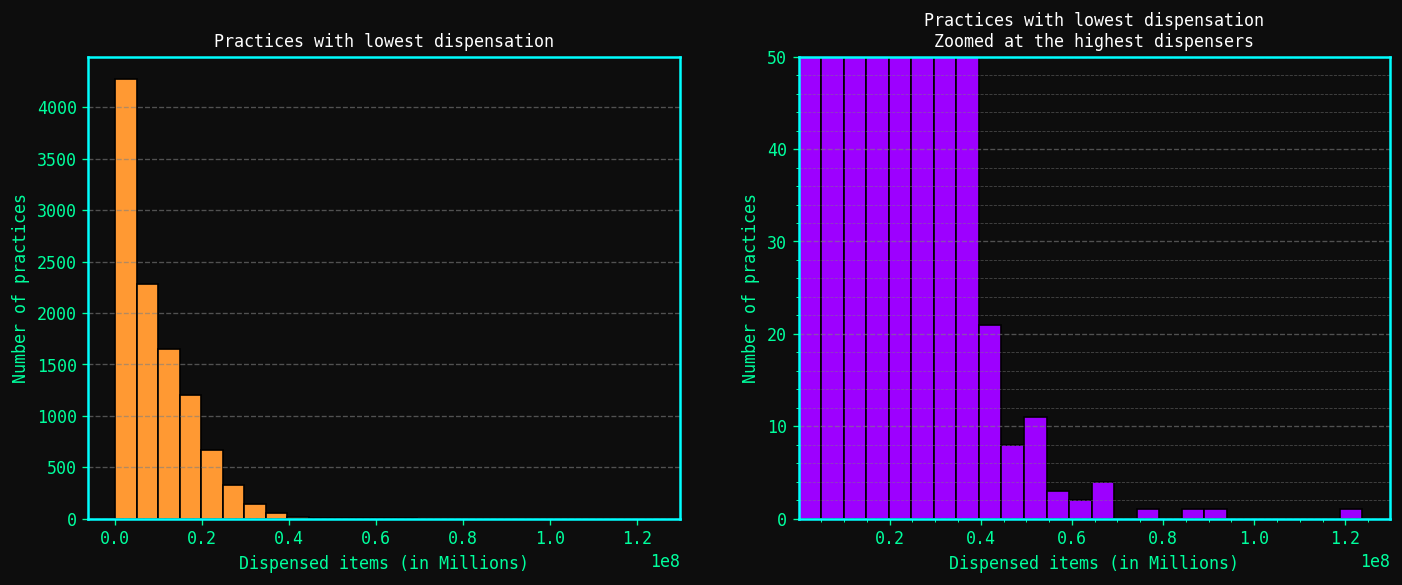

In [17]:

practice_quantity = df_final.groupby('practice')['quantity'].sum().reset_index()

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

ax[0].hist(practice_quantity['quantity'],
          bins=25,
          color=neon_colors[7],
          edgecolor='black')

ax[0].set_title('Practices with lowest dispensation', fontsize=10)
ax[0].set_ylabel('Number of practices')
ax[0].set_xlabel('Dispensed items (in Millions)')

ax[0].grid(axis='y', color='grey', linestyle='--', alpha=0.6, lw=0.8)

ax[1].hist(practice_quantity['quantity'],
          bins=25,
          color=neon_colors[8],
          edgecolor='black')
ax[1].set_ylim(0, 50)
ax[1].set_xlim(0.5, )
ax[1].set_title('Practices with lowest dispensation\nZoomed at the highest dispensers', fontsize=10)
ax[1].set_ylabel('Number of practices')
ax[1].set_xlabel('Dispensed items (in Millions)')

ax[1].minorticks_on()
ax[1].grid(which='major', axis='y', color='grey', linestyle='--', alpha=0.6, lw=0.8)
ax[1].grid(which='minor', axis='y', color='grey', linestyle='--', alpha=0.5, lw=0.5)

plt.savefig('dispensation_practices.png', dpi=300, bbox_inches='tight')
plt.show()

### This graph is showing top 10 spenders (practices)

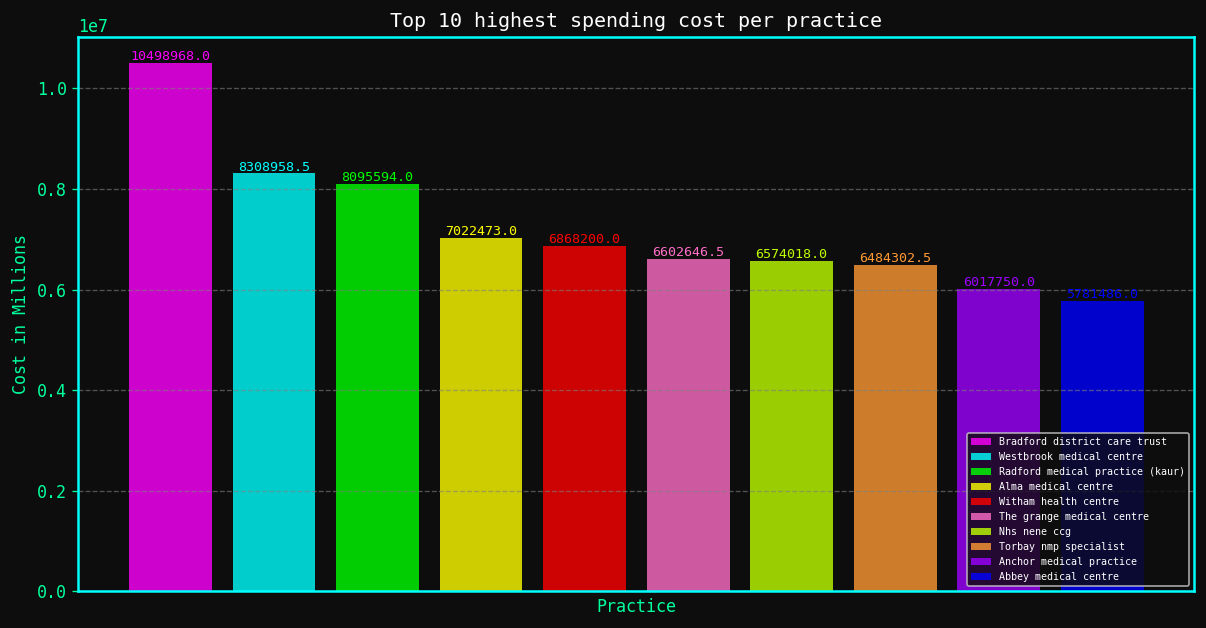

In [12]:
practice_name_cost = df_final.groupby(['practice', 'practice_name'],  observed=False)['act_cost'].sum().sort_values(ascending=False).reset_index().head(10)

plt.figure(figsize=(12, 6))
plt.bar(practice_name_cost['practice_name'],
        practice_name_cost['act_cost'],
        color=neon_colors,
        label=practice_name_cost['practice_name'],
        alpha=0.8)

for i in range(len(practice_name_cost)):
    plt.text(practice_name_cost['practice_name'].iloc[i],
             practice_name_cost['act_cost'].iloc[i],
             f"{practice_name_cost['act_cost'].iloc[i]}",
             ha='center',
             va='bottom',
             color=neon_colors[i],
             alpha=1,
             fontsize=8)

plt.title('Top 10 highest spending cost per practice')
plt.ylabel('Cost in Millions')
plt.xlabel('Practice')
plt.xticks([])
plt.grid(axis='y', color='grey', linestyle='--', alpha=0.6, lw=0.8)
plt.legend(loc='lower right', prop={'size':6})
plt.show()